# SQL Queries

In [ ]:
!pip install ipython-sql
!pip install ipython-sql prettytable

In [23]:
%reload_ext sql

In [24]:
import csv, sqlite3
import prettytable
prettytable.DEFAULT = 'DEFAULT'

con = sqlite3.connect("my_data1.db")
cur = con.cursor()

In [25]:
%sql sqlite:///my_data1.db

In [26]:
import pandas as pd
df = pd.read_csv("https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/labs/module_2/data/Spacex.csv")
df.to_sql("SPACEXTBL", con, if_exists='replace', index=False,method="multi")

101

In [27]:
#DROP THE TABLE IF EXISTS
%sql DROP TABLE IF EXISTS SPACEXTABLE;

 * sqlite:///my_data1.db
Done.


[]

In [28]:
%sql create table SPACEXTABLE as select * from SPACEXTBL where Date is not null

 * sqlite:///my_data1.db
Done.


[]

In [43]:
df

,Date,Time (UTC),Booster_Version,Launch_Site,Payload,PAYLOAD_MASS__KG_,Orbit,Customer,Mission_Outcome,Landing_Outcome
0,2010-06-04,18:45:00,F9 v1.0 B0003,CCAFS LC-40,Dragon Spacecraft Qualification Unit,0,LEO,SpaceX,Success,Failure (parachute)
1,2010-12-08,15:43:00,F9 v1.0 B0004,CCAFS LC-40,"Dragon demo flight C1, two CubeSats, barrel of...",0,LEO (ISS),NASA (COTS) NRO,Success,Failure (parachute)
2,2012-05-22,7:44:00,F9 v1.0 B0005,CCAFS LC-40,Dragon demo flight C2,525,LEO (ISS),NASA (COTS),Success,No attempt
3,2012-10-08,0:35:00,F9 v1.0 B0006,CCAFS LC-40,SpaceX CRS-1,500,LEO (ISS),NASA (CRS),Success,No attempt
4,2013-03-01,15:10:00,F9 v1.0 B0007,CCAFS LC-40,SpaceX CRS-2,677,LEO (ISS),NASA (CRS),Success,No attempt
...,...,...,...,...,...,...,...,...,...,...
96,2020-11-05,23:24:23,F9 B5B1062.1,CCAFS SLC-40,"GPS III-04 , Crew-1",4311,MEO,USSF,Success,Success
97,2020-11-16,0:27:00,F9 B5B1061.1,KSC LC-39A,"Crew-1, Sentinel-6 Michael Freilich",12500,LEO (ISS),NASA (CCP),Success,Success
98,2020-11-21,17:17:08,F9 B5B1063.1,VAFB SLC-4E,"Sentinel-6 Michael Freilich, Starlink 15 v1.0",1192,LEO,NASA / NOAA / ESA / EUMETSAT,Success,Success
99,2020-11-25,2:13:00,F9 B5 B1049.7,CCAFS SLC-40,"Starlink 15 v1.0, SpaceX CRS-21",15600,LEO,SpaceX,Success,Success


In [30]:
# Task 1 Display the names of the unique launch sites in the space mission
%sql SELECT DISTINCT(Launch_site) FROM SPACEXTABLE;

 * sqlite:///my_data1.db
Done.


Launch_Site
CCAFS LC-40
VAFB SLC-4E
KSC LC-39A
CCAFS SLC-40


In [ ]:
# Task 2 Display 5 records where launch sites begin with the string 'CCA'

In [32]:
%%sql
SELECT * FROM SPACEXTABLE
WHERE Launch_site LIKE 'CCA%'
LIMIT 5;

 * sqlite:///my_data1.db
Done.


Date,Time (UTC),Booster_Version,Launch_Site,Payload,PAYLOAD_MASS__KG_,Orbit,Customer,Mission_Outcome,Landing_Outcome
2010-06-04,18:45:00,F9 v1.0 B0003,CCAFS LC-40,Dragon Spacecraft Qualification Unit,0,LEO,SpaceX,Success,Failure (parachute)
2010-12-08,15:43:00,F9 v1.0 B0004,CCAFS LC-40,"Dragon demo flight C1, two CubeSats, barrel of Brouere cheese",0,LEO (ISS),NASA (COTS) NRO,Success,Failure (parachute)
2012-05-22,7:44:00,F9 v1.0 B0005,CCAFS LC-40,Dragon demo flight C2,525,LEO (ISS),NASA (COTS),Success,No attempt
2012-10-08,0:35:00,F9 v1.0 B0006,CCAFS LC-40,SpaceX CRS-1,500,LEO (ISS),NASA (CRS),Success,No attempt
2013-03-01,15:10:00,F9 v1.0 B0007,CCAFS LC-40,SpaceX CRS-2,677,LEO (ISS),NASA (CRS),Success,No attempt


In [ ]:
# Task 3 Display the total payload mass carried by boosters launched by NASA (CRS)

In [41]:
%%sql
SELECT Customer, SUM(Payload_mass__kg_) as `Total Payload Mass(kg)` FROM SPACEXTABLE
WHERE Customer == 'NASA (CRS)';

 * sqlite:///my_data1.db
Done.


Customer,Total Payload Mass(kg)
NASA (CRS),45596


In [39]:
# Task 4 Display average payload mass carried by booster version F9 v1.1

In [40]:
%%sql
SELECT Booster_version, AVG(Payload_mass__kg_) as `Average Payload Mass(kg)` FROM SPACEXTABLE
WHERE Booster_version == 'F9 v1.1';

 * sqlite:///my_data1.db
Done.


Booster_Version,Average Payload Mass(kg)
F9 v1.1,2928.4


In [42]:
# Task 5 List the date when the first succesful landing outcome in ground pad was acheived.
# Hint:Use min function

In [46]:
%%sql
SELECT min(DATE), Landing_outcome, Mission_outcome FROM SPACEXTABLE
WHERE Mission_outcome == 'Success' and Landing_outcome == 'Success (ground pad)';

 * sqlite:///my_data1.db
Done.


min(DATE),Landing_Outcome,Mission_Outcome
2015-12-22,Success (ground pad),Success


In [47]:
# Task 6 List the names of the boosters which have success in drone ship and have payload mass greater than 4000 but less than 6000

In [48]:
%%sql
SELECT Booster_version, Payload_mass__kg_, Landing_outcome FROM SPACEXTABLE
WHERE Landing_outcome = 'Success (drone ship)' and Payload_mass__kg_ > 4000 and Payload_mass__kg_ < 6000;

 * sqlite:///my_data1.db
Done.


Booster_Version,PAYLOAD_MASS__KG_,Landing_Outcome
F9 FT B1022,4696,Success (drone ship)
F9 FT B1026,4600,Success (drone ship)
F9 FT B1021.2,5300,Success (drone ship)
F9 FT B1031.2,5200,Success (drone ship)


In [49]:
# Task 7 List the total number of successful and failure mission outcomes

In [52]:
%%sql 
SELECT TRIM(Mission_outcome), COUNT(Mission_outcome) FROM SPACEXTABLE
GROUP BY TRIM(Mission_outcome);

 * sqlite:///my_data1.db
Done.


TRIM(Mission_outcome),COUNT(Mission_outcome)
Failure (in flight),1
Success,99
Success (payload status unclear),1


In [53]:
# Task 8 List all the booster_versions that have carried the maximum payload mass, using a subquery with a suitable aggregate function.

In [56]:
%%sql
SELECT Booster_version, Payload_mass__kg_ FROM SPACEXTABLE
WHERE Payload_mass__kg_ = (SELECT max(payload_mass__kg_) FROM SPACEXTABLE);

 * sqlite:///my_data1.db
Done.


Booster_Version,PAYLOAD_MASS__KG_
F9 B5 B1048.4,15600
F9 B5 B1049.4,15600
F9 B5 B1051.3,15600
F9 B5 B1056.4,15600
F9 B5 B1048.5,15600
F9 B5 B1051.4,15600
F9 B5 B1049.5,15600
F9 B5 B1060.2,15600
F9 B5 B1058.3,15600
F9 B5 B1051.6,15600


In [57]:
# Task 9 List the records which will display the month names, failure landing_outcomes in drone ship ,booster versions, launch_site for the months in year 2015.
# Note: SQLLite does not support monthnames. So you need to use substr(Date, 6,2) as month to get the months and substr(Date,0,5)='2015' for year.

In [58]:
%%sql 
SELECT substr(Date,0,5) as 'Year', substr(Date,6,2) as 'Month', Landing_outcome, Booster_version, Launch_site FROM SPACEXTABLE
WHERE Landing_outcome = "Failure (drone ship)" and substr(Date, 0,5) = "2015";

 * sqlite:///my_data1.db
Done.


Year,Month,Landing_Outcome,Booster_Version,Launch_Site
2015,01,Failure (drone ship),F9 v1.1 B1012,CCAFS LC-40
2015,04,Failure (drone ship),F9 v1.1 B1015,CCAFS LC-40


In [59]:
# Task 10 Rank the count of landing outcomes (such as Failure (drone ship) or Success (ground pad)) between the date 2010-06-04 and 2017-03-20, in descending order.

In [60]:
%%sql
SELECT Landing_outcome, Count(*) FROM SPACEXTABLE
WHERE Date Between '2010-06-04' and '2017-03-20'
GROUP BY Landing_outcome
ORDER BY Count(*) DESC;

 * sqlite:///my_data1.db
Done.


Landing_Outcome,Count(*)
No attempt,10
Success (drone ship),5
Failure (drone ship),5
Success (ground pad),3
Controlled (ocean),3
Uncontrolled (ocean),2
Failure (parachute),2
Precluded (drone ship),1


# Data Visualization

In [61]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [62]:
df = pd.read_csv("dataset_part_02.csv")
df.head()

,FlightNumber,Date,BoosterVersion,PayloadMass,Orbit,LaunchSite,Outcome,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial,Longitude,Latitude,Class
0,1,2010-06-04,Falcon 9,6104.959412,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0003,-80.577366,28.561857,0
1,2,2012-05-22,Falcon 9,525.000000,LEO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0005,-80.577366,28.561857,0
2,3,2013-03-01,Falcon 9,677.000000,ISS,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B0007,-80.577366,28.561857,0
3,4,2013-09-29,Falcon 9,500.000000,PO,VAFB SLC 4E,False Ocean,1,False,False,False,NaN,1.0,0,B1003,-120.610829,34.632093,0
4,5,2013-12-03,Falcon 9,3170.000000,GTO,CCAFS SLC 40,None None,1,False,False,False,NaN,1.0,0,B1004,-80.577366,28.561857,0


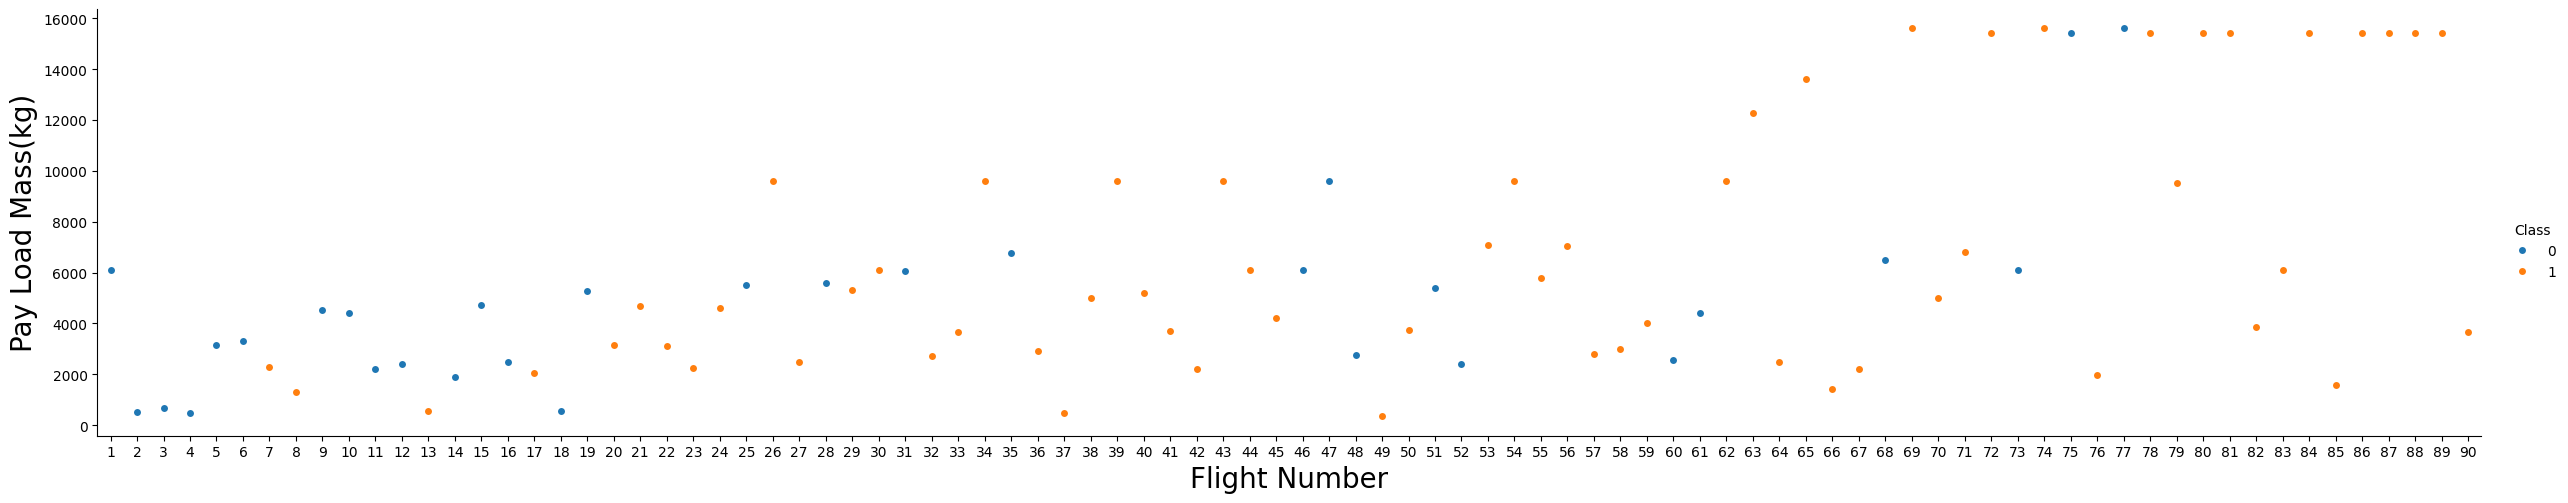

In [63]:
sns.catplot(data=df, x="FlightNumber", y="PayloadMass", hue="Class", aspect=5)
plt.xlabel("Flight Number", fontsize=20)
plt.ylabel("Pay Load Mass(kg)", fontsize=20)
plt.show()

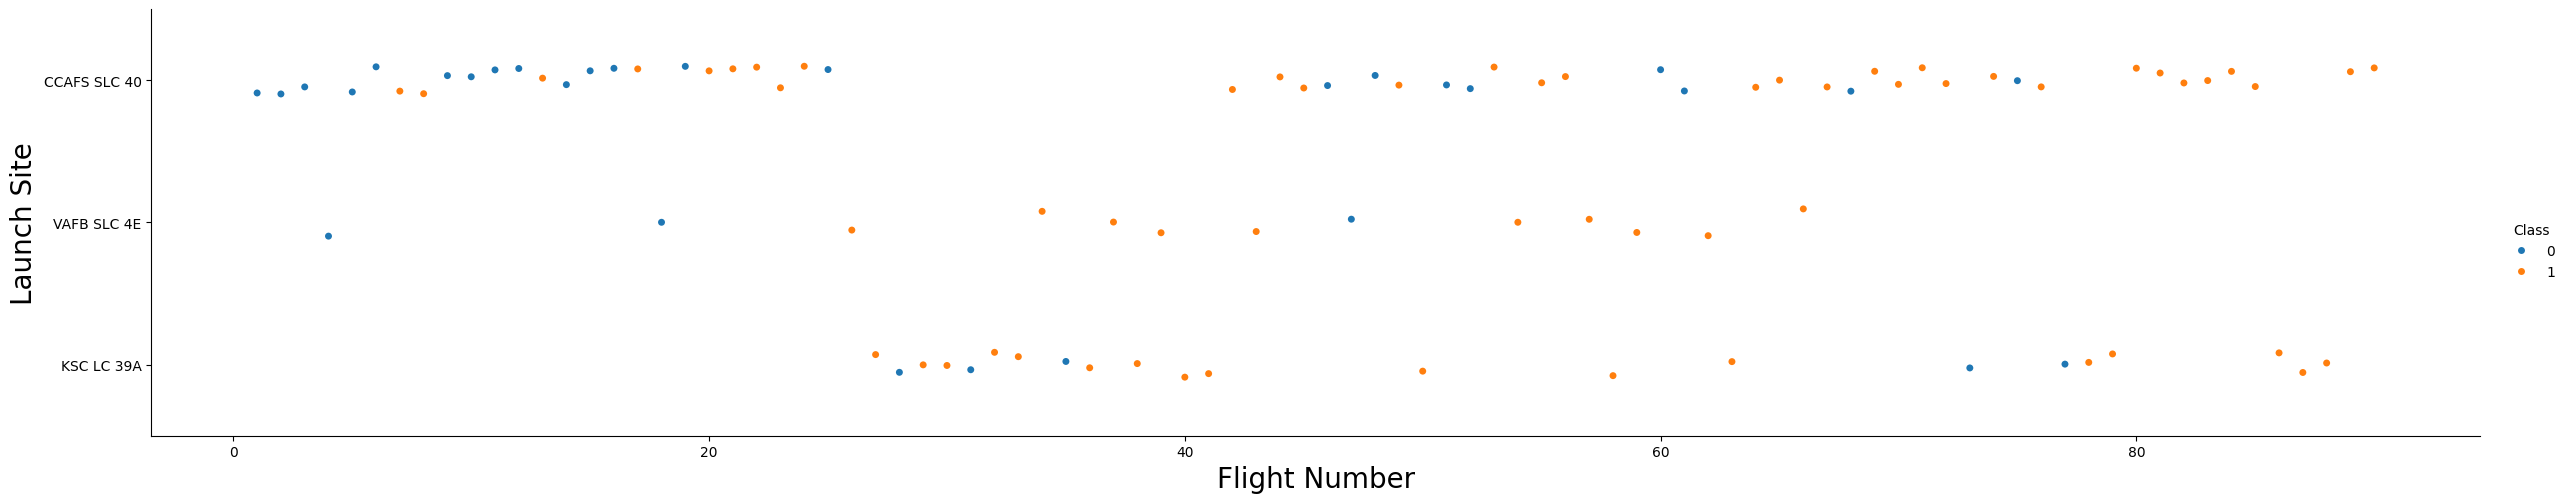

In [74]:
# TASK 1: Visualize the relationship between Flight Number and Launch Site
# Use the function catplot to plot FlightNumber vs LaunchSite, set the parameter x parameter to FlightNumber,set the y to Launch Site and set the parameter hue to 'class'
sns.catplot(data=df, x="FlightNumber", y="LaunchSite", hue="Class", aspect=5)
plt.xlabel("Flight Number", fontsize=20)
plt.ylabel("Launch Site", fontsize=20)
plt.show()

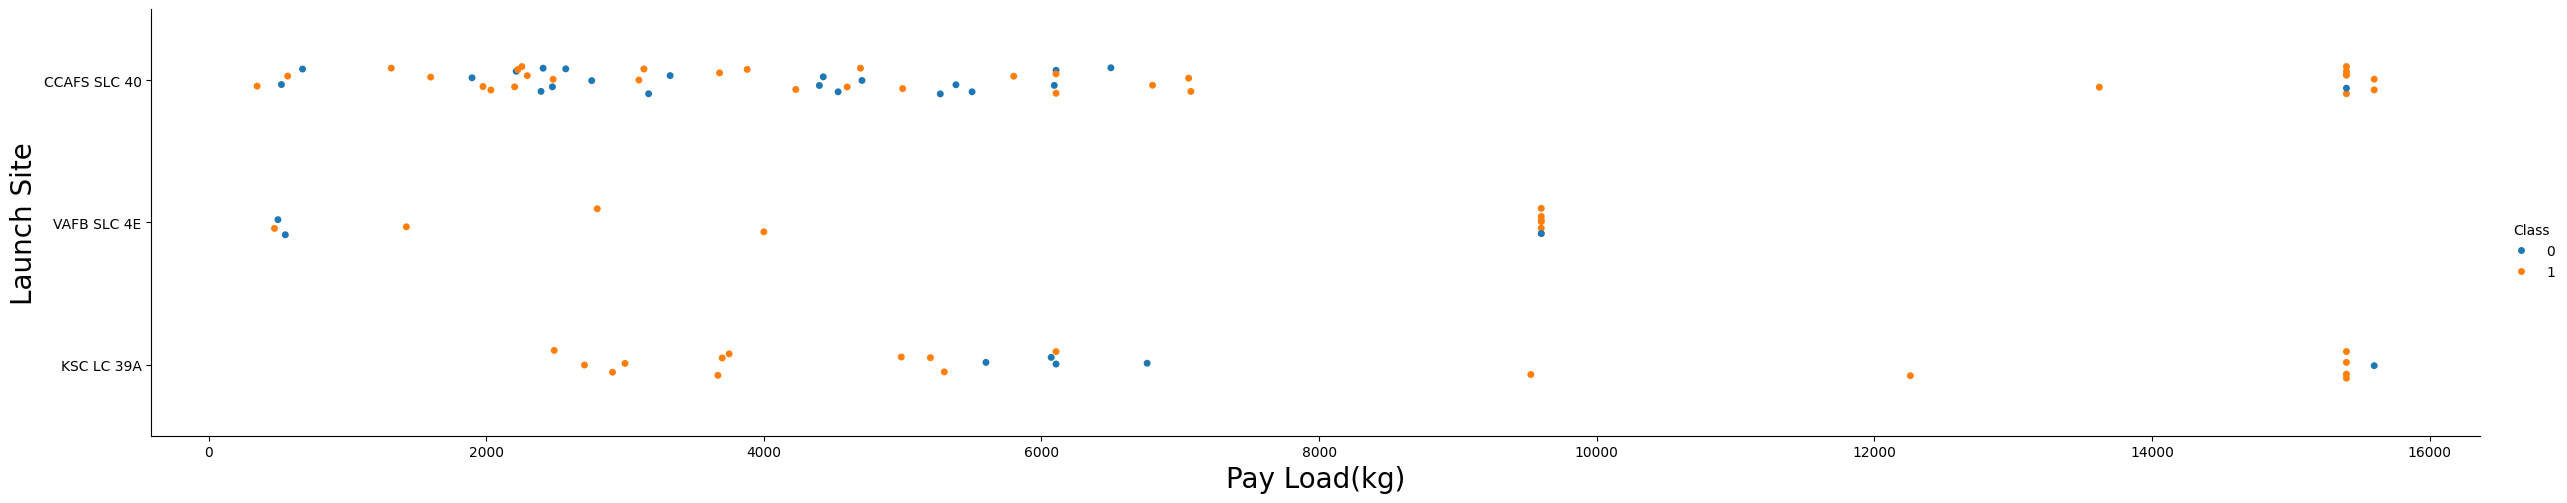

In [73]:
# TASK 2: Visualize the relationship between Payload and Launch Site
sns.catplot(data=df, x="PayloadMass", y="LaunchSite", hue="Class", aspect=5)
plt.xlabel("Pay Load(kg)", fontsize=20)
plt.ylabel("Launch Site", fontsize=20)
plt.show()

<Axes: xlabel='Orbit'>

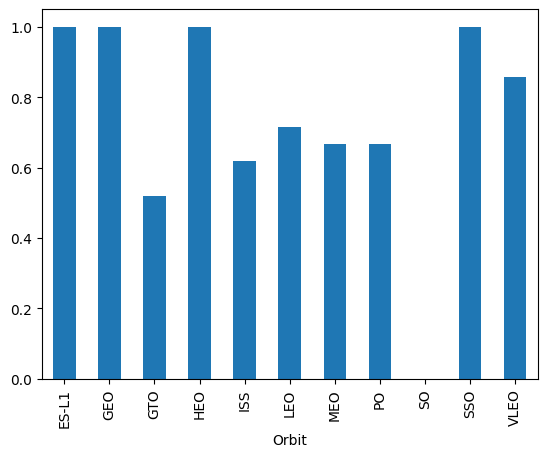

In [72]:
# TASK 3: Visualize the relationship between success rate of each orbit type
orbit_success = df.groupby(by="Orbit")["Class"].mean()
orbit_success.plot(kind="bar")

C:\Users\admin\AppData\Local\Temp\ipykernel_8108\491209719.py:1: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=orbit_success, palette="rainbow")


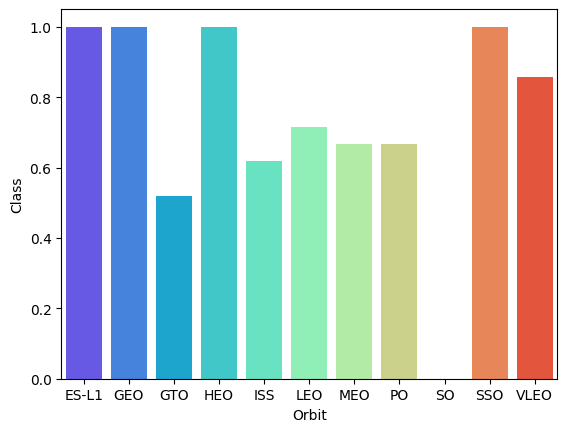

In [75]:
sns.barplot(data=orbit_success, palette="rainbow")
plt.show()

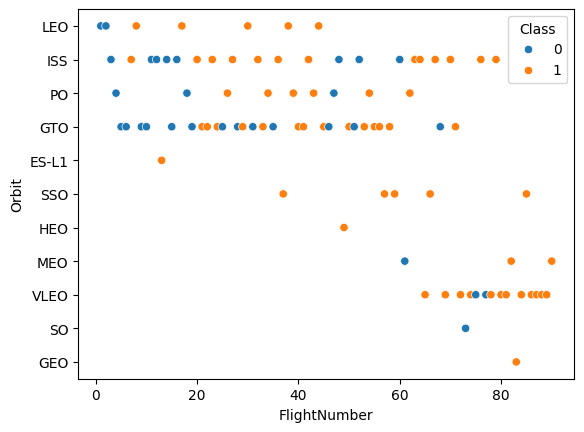

In [76]:
# TASK 4: Visualize the relationship between FlightNumber and Orbit type
sns.scatterplot(data=df, x="FlightNumber", y="Orbit", hue="Class")
plt.show()

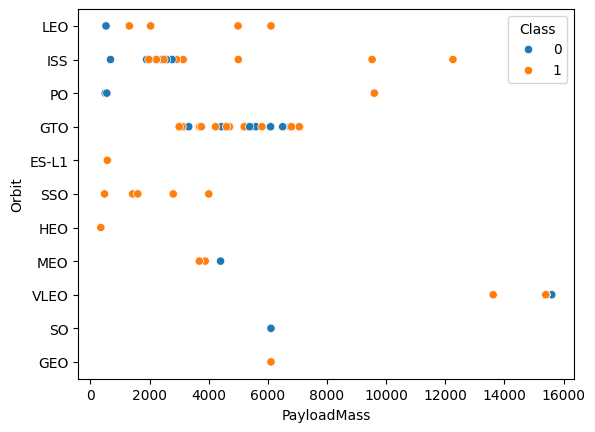

In [77]:
# TASK 5: Visualize the relationship between Payload and Orbit type
sns.scatterplot(data=df, x="PayloadMass", y="Orbit", hue="Class")
plt.show()

<Axes: xlabel='Year', ylabel='Class'>

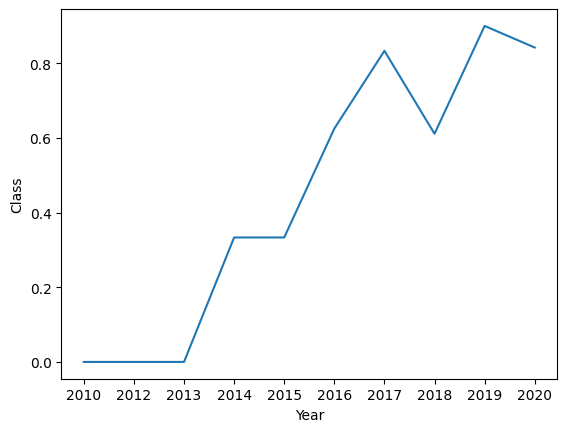

In [78]:
# TASK 6: Visualize the launch success yearly trend
def Extract_year(date):
    year = []
    for i in df["Date"]:
        year.append(i.split("-")[0])
    return year

Extract_year(df)

df["Year"] = Extract_year(df["Date"])

yearly_success = df.groupby("Year")["Class"].mean().reset_index()

sns.lineplot(data=yearly_success, x="Year", y="Class")

# Features Engineering

In [79]:
features = df[['FlightNumber', 'PayloadMass', 'Orbit', 'LaunchSite', 'Flights', 'GridFins', 'Reused', 'Legs', 'LandingPad', 'Block', 'ReusedCount', 'Serial']]
features.head()

,FlightNumber,PayloadMass,Orbit,LaunchSite,Flights,GridFins,Reused,Legs,LandingPad,Block,ReusedCount,Serial
0,1,6104.959412,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0003
1,2,525.000000,LEO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0005
2,3,677.000000,ISS,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B0007
3,4,500.000000,PO,VAFB SLC 4E,1,False,False,False,NaN,1.0,0,B1003
4,5,3170.000000,GTO,CCAFS SLC 40,1,False,False,False,NaN,1.0,0,B1004


In [80]:
# TASK 7: Create dummy variables to categorical columns
features_one_hot = pd.get_dummies(data=features, columns=["Orbit", "LaunchSite", "LandingPad", "Serial"])
features_one_hot

,FlightNumber,PayloadMass,Flights,GridFins,Reused,Legs,Block,ReusedCount,Orbit_ES-L1,Orbit_GEO,...,Serial_B1048,Serial_B1049,Serial_B1050,Serial_B1051,Serial_B1054,Serial_B1056,Serial_B1058,Serial_B1059,Serial_B1060,Serial_B1062
0,1,6104.959412,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
1,2,525.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
2,3,677.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
3,4,500.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
4,5,3170.000000,1,False,False,False,1.0,0,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
85,86,15400.000000,2,True,True,True,5.0,2,False,False,...,False,False,False,False,False,False,False,False,True,False
86,87,15400.000000,3,True,True,True,5.0,2,False,False,...,False,False,False,False,False,False,True,False,False,False
87,88,15400.000000,6,True,True,True,5.0,5,False,False,...,False,False,False,True,False,False,False,False,False,False
88,89,15400.000000,3,True,True,True,5.0,2,False,False,...,False,False,False,False,False,False,False,False,True,False


In [81]:
# TASK 8: Cast all numeric columns to float64
features_one_hot = features_one_hot.astype("float64")

In [82]:
features_one_hot.to_csv('dataset_part_03.csv', index=False)

# Data Visualization using Folium

In [3]:
!pip3 install wget
import folium
import wget
import pandas as pd

  Using cached wget-3.2.zip (10 kB)
  Preparing metadata (setup.py): started
  Preparing metadata (setup.py): finished with status 'done'
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9680 sha256=dbfd6d046699d8430190b67299d5b3e00d18128d6bb210e5cdaecb7771db16d3
  Stored in directory: c:\users\admin\appdata\local\pip\cache\wheels\01\46\3b\e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget


In [2]:
# Import folium MarkerCluster plugin
from folium.plugins import MarkerCluster
# Import folium MousePosition plugin
from folium.plugins import MousePosition
# Import folium DivIcon plugin
from folium.features import DivIcon

In [4]:
# Task 1: Mark all launch sites on a map

In [5]:
spacex_csv_file = wget.download('https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-DS0321EN-SkillsNetwork/datasets/spacex_launch_geo.csv')
spacex_df=pd.read_csv(spacex_csv_file)

100% [................................................................................] 7710 / 7710

In [6]:
# Select relevant sub-columns: `Launch Site`, `Lat(Latitude)`, `Long(Longitude)`, `class`
spacex_df = spacex_df[['Launch Site', 'Lat', 'Long', 'class']]
launch_sites_df = spacex_df.groupby(['Launch Site'], as_index=False).first()
launch_sites_df = launch_sites_df[['Launch Site', 'Lat', 'Long']]
launch_sites_df

,Launch Site,Lat,Long
0,CCAFS LC-40,28.562302,-80.577356
1,CCAFS SLC-40,28.563197,-80.576820
2,KSC LC-39A,28.573255,-80.646895
3,VAFB SLC-4E,34.632834,-120.610745


In [7]:
# Start location is NASA Johnson Space Center
nasa_coordinate = [29.559684888503615, -95.0830971930759]
site_map = folium.Map(location=nasa_coordinate, zoom_start=10)

In [9]:
# Create a blue circle at NASA Johnson Space Center's coordinate with a popup label showing its name
circle = folium.Circle(nasa_coordinate, radius=1000, color='Blue', fill=True).add_child(folium.Popup('NASA Johnson Space Center'))
# Create a blue circle at NASA Johnson Space Center's coordinate with a icon showing its name
marker = folium.map.Marker(
    nasa_coordinate,
    # Create an icon as a text label
    icon=DivIcon(
        icon_size=(20,20),
        icon_anchor=(0,0),
        html='<div style="font-size: 12; color:Blue;"><b>%s</b></div>' % 'NASA JSC',
        )
    )
site_map.add_child(circle)
site_map.add_child(marker)

In [12]:
# Initial the map
site_map = folium.Map(location=nasa_coordinate, zoom_start=5)
# For each launch site, add a Circle object based on its coordinate (Lat, Long) values. In addition, add Launch site name as a popup label
for launch_site, site_lat, site_long in zip(launch_sites_df['Launch Site'], launch_sites_df['Lat'], launch_sites_df['Long']):
    site_coordinate = [site_lat, site_long]
    
    circle = folium.Circle(site_coordinate, radius=1000, color='#d35400', fill=True).add_child(folium.Popup(launch_site))
    
    marker = folium.map.Marker(
        site_coordinate,
        # Create an icon as a text label
        icon=DivIcon(
            icon_size=(20, 20),
            icon_anchor=(0, 0),
            html='<div style="font-size: 12; color:#d35400;"><b>%s</b></div>' % launch_site,
            )
        )
    site_map.add_child(circle)
    site_map.add_child(marker)
site_map

In [16]:
# Task 2: Mark the success/failed launches for each site on the map 

In [17]:
def assign_marker_color(launch_outcome):
    if launch_outcome == 1:
        return 'green'
    else:
        return 'red'
    
spacex_df['marker_color'] = spacex_df['class'].apply(assign_marker_color)
spacex_df.tail(10)

,Launch Site,Lat,Long,class,marker_color
46,KSC LC-39A,28.573255,-80.646895,1,green
47,KSC LC-39A,28.573255,-80.646895,1,green
48,KSC LC-39A,28.573255,-80.646895,1,green
49,CCAFS SLC-40,28.563197,-80.576820,1,green
50,CCAFS SLC-40,28.563197,-80.576820,1,green
51,CCAFS SLC-40,28.563197,-80.576820,0,red
52,CCAFS SLC-40,28.563197,-80.576820,0,red
53,CCAFS SLC-40,28.563197,-80.576820,0,red
54,CCAFS SLC-40,28.563197,-80.576820,1,green
55,CCAFS SLC-40,28.563197,-80.576820,0,red


In [18]:
from folium.plugins import MarkerCluster

marker_cluster = MarkerCluster()
site_map.add_child(marker_cluster)

for index, record in spacex_df.iterrows():

    marker = folium.Marker(
        location=[record['Lat'], record['Long']],
        icon=folium.Icon(
            color=record['marker_color'],
            icon='info-sign'
        )
    )

    marker_cluster.add_child(marker)

site_map

In [19]:
# TASK 3: Calculate the distances between a launch site to its proximities

In [20]:
# Add Mouse Position to get the coordinate (Lat, Long) for a mouse over on the map
formatter = "function(num) {return L.Util.formatNum(num, 5);};"
mouse_position = MousePosition(
    position='topright',
    separator=' Long: ',
    empty_string='NaN',
    lng_first=False,
    num_digits=20,
    prefix='Lat:',
    lat_formatter=formatter,
    lng_formatter=formatter,
)

site_map.add_child(mouse_position)
site_map

In [21]:
from math import sin, cos, sqrt, atan2, radians

def calculate_distance(lat1, lon1, lat2, lon2):
    # approximate radius of earth in km
    R = 6373.0

    lat1 = radians(lat1)
    lon1 = radians(lon1)
    lat2 = radians(lat2)
    lon2 = radians(lon2)

    dlon = lon2 - lon1
    dlat = lat2 - lat1

    a = sin(dlat / 2)**2 + cos(lat1) * cos(lat2) * sin(dlon / 2)**2
    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    distance = R * c
    return distance

In [22]:
launch_site_lat = 28.563197
launch_site_lon = -80.576820
coastline_lat = 28.56334
coastline_lon = -80.56799
distance_coastline = calculate_distance(launch_site_lat, launch_site_lon, coastline_lat, coastline_lon)
print(distance_coastline,' km')

0.8627671182499878  km


In [23]:
distance_marker = folium.Marker(
   [coastline_lat, coastline_lon],
   icon=DivIcon(
       icon_size=(20,20),
       icon_anchor=(0,0),
       html='<div style="font-size: 12; color:#FF0000;"><b>%s</b></div>' % "{:10.2f} KM".format(distance_coastline),
       )
   )
site_map.add_child(distance_marker)

In [24]:
coordinates = [[launch_site_lat,launch_site_lon],[coastline_lat,coastline_lon]]
lines=folium.PolyLine(locations=coordinates, weight=1)
site_map.add_child(lines)

In [25]:
launch_coordinate = [28.562302, -80.57682]

city   = [28.61200, -80.80788]
railway = [28.55752, -80.80155]
highway   = [28.5402, -80.85079]

city_distance = calculate_distance(city[0], city[1], launch_coordinate[0], launch_coordinate[1])
railway_distance = calculate_distance(railway[0], railway[1], launch_coordinate[0], launch_coordinate[1])
highway_distance = calculate_distance(highway[0], highway[1], launch_coordinate[0], launch_coordinate[1])

colors = ['red','orange','green']
html_colors = ['#dc3545','#fd7e14','#198754']

for coordinate ,distance, color, html_color in zip([city, railway, highway], [city_distance, railway_distance, highway_distance], colors, html_colors):
    marker = folium.map.Marker(
            coordinate,
            # Create an icon as a text label
            icon=DivIcon(
                icon_size=(20,20),
                icon_anchor=(0,0),
                html=f'<div style="font-size:12px; color:{html_color};"><b>{round(distance,2)} km</b></div>',
            )
            )
    marker.add_to(site_map)
    folium.PolyLine([coordinate, launch_coordinate], color=color).add_to(site_map)

site_map.add_child(lines)

# Creating Dashboard using Plotly

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import dash
from dash import html, dcc
from dash.dependencies import Input, Output
import plotly.express as px

# Read the airline data into pandas dataframe
spacex_df = pd.read_csv("spacex_launch_dash.csv")
max_payload = spacex_df['Payload Mass (kg)'].max()
min_payload = spacex_df['Payload Mass (kg)'].min()

launch_sites = []
launch_sites.append({'label': 'All Sites', 'value': 'All Sites'})
all_launch_sites = spacex_df['Launch Site'].unique().tolist()
for launch_site in all_launch_sites:
    launch_sites.append({'label': launch_site, 'value': launch_site})

# Create a dash application
app = dash.Dash(__name__)

# Create an app layout
app.layout = html.Div(children=[html.H1('SpaceX Launch Records Dashboard',
                                        style={'textAlign': 'center', 'color': '#503D36',
                                               'font-size': 40}),
                                # TASK 1: Add a dropdown list to enable Launch Site selection
                                # The default select value is for ALL sites
                                # dcc.Dropdown(id='site-dropdown',...)
                                html.Div([
                                    dcc.Dropdown(
                                        id = 'site-dropdown',
                                        options = launch_sites,
                                        placeholder = 'Select a Launch Site here',
                                        searchable = True ,
                                        clearable = False,
                                        value = 'All Sites'
                                        ),]),
                                html.Br(),

                                # TASK 2: Add a pie chart to show the total successful launches count for all sites
                                # If a specific launch site was selected, show the Success vs. Failed counts for the site
                                html.Div(dcc.Graph(id='success-pie-chart')),
                                html.Br(),

                                html.P("Payload range (Kg):"),
                                # TASK 3: Add a slider to select payload range
                                #dcc.RangeSlider(id='payload-slider',...)
                                html.Div([
                                    dcc.RangeSlider(
                                        id = 'payload_slider',
                                        min = 0,
                                        max = 10000,
                                        step = 1000,
                                        marks = {
                                            0: {'label': '0 Kg', 'style': {'color': '#77b0b1'}},
                                            1000: {'label': '1000 Kg'},
                                            2000: {'label': '2000 Kg'},
                                            3000: {'label': '3000 Kg'},
                                            4000: {'label': '4000 Kg'},
                                            5000: {'label': '5000 Kg'},
                                            6000: {'label': '6000 Kg'},
                                            7000: {'label': '7000 Kg'},
                                            8000: {'label': '8000 Kg'},
                                            9000: {'label': '9000 Kg'},
                                            10000: {'label': '10000 Kg', 'style': {'color': '#f50'}},
                                            },
                                            value = [min_payload,max_payload]),
                                            ]),

                                # TASK 4: Add a scatter chart to show the correlation between payload and launch success
                                html.Div(dcc.Graph(id='success-payload-scatter-chart')),
                                ])

# TASK 2:
# Add a callback function for `site-dropdown` as input, `success-pie-chart` as output
@app.callback(
     Output(component_id = 'success-pie-chart', component_property = 'figure'),
     [Input(component_id = 'site-dropdown', component_property = 'value')]
)
def update_piegraph(site_dropdown):
    if (site_dropdown == 'All Sites' or site_dropdown == 'None'):
        data  = spacex_df[spacex_df['class'] == 1] 
        fig = px.pie(
                data,
                names = 'Launch Site',
                title = 'Total Success Launches by All Sites',
            )
    else:
        data  = spacex_df.loc[spacex_df['Launch Site'] == site_dropdown]
        fig = px.pie(
                data,
                names = 'class',
                title = 'Total Success Launches for Site &#8608; '+site_dropdown,
            )
    return fig

# TASK 3:
# Add a callback function for `site-dropdown` and `payload-slider` as inputs, `success-payload-scatter-chart` as output
@app.callback(
     Output(component_id = 'success-payload-scatter-chart', component_property = 'figure'),
     [Input(component_id = 'site-dropdown', component_property = 'value'), 
     Input(component_id = "payload_slider", component_property = "value")]
)
def update_scattergraph(site_dropdown,payload_slider):
    if (site_dropdown == 'All Sites' or site_dropdown == 'None'):
        low, high = payload_slider
        data  = spacex_df
        inrange = (data['Payload Mass (kg)'] > low) & (data['Payload Mass (kg)'] < high)
        fig = px.scatter(
                data[inrange], 
                x = "Payload Mass (kg)", 
                y = "class",
                title = 'Correlation Between Payload and Success for All Sites',
                color="Booster Version Category",
                size='Payload Mass (kg)',
                hover_data=['Payload Mass (kg)']
            )
    else:
        low, high = payload_slider
        data  = spacex_df.loc[spacex_df['Launch Site'] == site_dropdown]
        inrange = (data['Payload Mass (kg)'] > low) & (data['Payload Mass (kg)'] < high)
        fig = px.scatter(
                data[inrange],
                x = "Payload Mass (kg)",
                y = "class",
                title = 'Correlation Between Payload and Success for Site &#8608; '+site_dropdown,
                color="Booster Version Category",
                size='Payload Mass (kg)',
                hover_data=['Payload Mass (kg)']
            )
    return fig

# Run the app
if __name__ == '__main__':
    app.run()